# Thesis — Step 4: Comparison Across Survey Rounds (final)

**Part A, secondary analysis.** How food insecurity and shocks changed across Rounds 4 to 8.

**Part B, additional analysis.** Whether the predictive relationships found in Round 8 hold in other rounds. A difference in performance between rounds may reflect both genuine change over time and differences introduced by harmonising the questionnaires, and this is stated as a limitation wherever it applies.

Two points govern the whole notebook. The DIEM rounds are repeated cross sections, not a panel, so prevalences can be compared but individual households cannot be followed. And coverage and questionnaire changed between rounds, so comparisons are restricted to common provinces and harmonised variables.

The middle food consumption category is reported with the standard WFP name, Borderline. DIEM labels it Moderate.



## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_auc_score
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 250)

RANDOM_STATE = 42
CLASSES = ['Poor', 'Borderline', 'Acceptable']
YMAP = {c: i for i, c in enumerate(CLASSES)}
INV = {i: c for c, i in YMAP.items()}
COLOURS = {'Poor': '#c0392b', 'Borderline': '#e8b34a', 'Acceptable': '#5b9e5b'}

ROUNDS = {4: 'R4 Mar-Apr 2022', 5: 'R5 Jul-Aug 2022', 6: 'R6 Jan-Feb 2023',
          7: 'R7 Sep-Oct 2023', 8: 'R8 Jan-Feb 2024'}
print('ready')

ready


## 2. Harmonising the variables that changed between rounds

The questionnaire was not identical across rounds, and five variables were recorded on different scales. The mappings below were checked against the data rather than assumed.

Round 6 recorded drinking water only as safe or unsafe, while the other rounds recorded the actual source. Counting spring water as safe gives Round 8 a safe share of 74.5 percent, almost exactly Round 6's 73.1 percent, whereas counting it as unsafe gives 62.3 percent.

Sanitation is the more important case. Round 6 classifies only 3.5 percent of households as having an improved toilet, which matches the share of flush latrines in Round 8, 3.7 percent. So Round 6's improved category corresponds to flush latrines alone. The usual international definition, which also counts pit latrines as improved, would have given 86 percent in Round 8 and an entirely artificial collapse in sanitation between rounds.

In [2]:
SAFE_WATER = {'Bottled water', 'Other safe source', 'Private tap from piped water',
              'Protected well', 'Public tap', 'Spring water', 'Safe drinking water'}

IMPROVED_TOILET = {'Flush latrine (toilet with water)', 'Improved toilet facility'}

ELECTRIC = {'Electricity (from generator or electrical grid or solar panel)',
            'Electricity (from generator or electrical grid)', 'Solar panel'}

EDUCATION = {
    'None or did not complete primary school': 'No education',
    'No basic education': 'No education',
    'No education': 'No education',
    'Completed primary school': 'Basic',
    'Completed secondary school': 'Basic',
    'Basic education': 'Basic',
    'Religious or informal education only': 'Basic',
    'Completed higher education (university, college) degree': 'Higher',
    'Higher education': 'Higher',
}

def harmonise(d):
    d = d.copy()
    d['fcg'] = d['fcg'].replace({'Moderate': 'Borderline'})
    d['hh_wealth_water'] = np.where(d['hh_wealth_water'].isin(SAFE_WATER), 'Safe',
                           np.where(d['hh_wealth_water'].eq('Not applicable'), 'Not applicable', 'Unsafe'))
    d['hh_wealth_toilet'] = np.where(d['hh_wealth_toilet'].isin(IMPROVED_TOILET), 'Improved',
                            np.where(d['hh_wealth_toilet'].eq('Not applicable'), 'Not applicable', 'Unimproved'))
    if 'hh_wealth_light' in d.columns:
        d['hh_wealth_light'] = np.where(d['hh_wealth_light'].isin(ELECTRIC),
                                        'Electricity or solar', 'No electric supply')
    d['hh_education'] = d['hh_education'].map(EDUCATION).fillna('Not applicable')
    d['hh_residencetype'] = np.where(d['hh_residencetype'].astype(str).str.startswith('Permanent'), 'Permanent',
                             np.where(d['hh_residencetype'].eq('Not applicable'), 'Not applicable', 'Non permanent'))
    d['need_received_food'] = d['need_received_food'].replace({'Not applicable': 'No'})
    return d

rounds = {r: harmonise(pd.read_csv('clean_R' + str(r) + '.csv')) for r in ROUNDS}
print('loaded and harmonised:', list(rounds))
print('categories in Round 8:', sorted(rounds[8]['fcg'].unique()))

loaded and harmonised: [4, 5, 6, 7, 8]
categories in Round 8: ['Acceptable', 'Borderline', 'Poor']


## 3. Checking that the harmonisation behaves sensibly

A wrong mapping would show up as a sudden jump between rounds. These shares should move gradually.

In [3]:
check = pd.DataFrame({
    'safe water %':      {r: d['hh_wealth_water'].eq('Safe').mean() * 100 for r, d in rounds.items()},
    'improved toilet %': {r: d['hh_wealth_toilet'].eq('Improved').mean() * 100 for r, d in rounds.items()},
    'no education %':    {r: d['hh_education'].eq('No education').mean() * 100 for r, d in rounds.items()},
    'households':        {r: len(d) for r, d in rounds.items()},
}).round(1)
print(check)

   safe water %  improved toilet %  no education %  households
4          74.8                4.9            61.7        5688
5          72.8                2.2            64.7        6019
6          73.1                3.5            71.7        6082
7          78.4                3.7            69.8        9560
8          74.5                3.7            68.7        9494


## 4. Which provinces can be compared?

Coverage grew from 25 provinces in Round 4 to 34 in Rounds 7 and 8. Comparisons are restricted to the provinces present in all rounds compared, otherwise a change could simply reflect new provinces entering the sample.

In [4]:
province_sets = {r: set(d['adm1_name']) - {'Not applicable'} for r, d in rounds.items()}
common_all = sorted(set.intersection(*province_sets.values()))
common_68 = sorted(province_sets[6] & province_sets[8])

print('provinces per round:', {r: len(s) for r, s in province_sets.items()})
print('common to all five rounds:', len(common_all))
print('common to Rounds 6 and 8: ', len(common_68))

provinces per round: {4: 25, 5: 25, 6: 26, 7: 34, 8: 34}
common to all five rounds: 24
common to Rounds 6 and 8:  26


# PART A — Secondary analysis: change across rounds

## 5. How did food consumption change?

Survey weights are used, since this describes the population rather than training a model. The figures are shown on the full samples and on the common provinces, so the effect of the restriction is visible.

In [5]:
def weighted_shares(d):
    w = d.groupby('fcg')['weight_final'].sum()
    return w / w.sum() * 100

full, restricted = {}, {}
for r, d in rounds.items():
    full[ROUNDS[r]] = weighted_shares(d)
    restricted[ROUNDS[r]] = weighted_shares(d[d['adm1_name'].isin(common_all)])

print('ALL PROVINCES (weighted %)')
print(pd.DataFrame(full).T[CLASSES].round(1))
print()
print('COMMON PROVINCES ONLY (weighted %)')
trend = pd.DataFrame(restricted).T[CLASSES].round(1)
print(trend)
trend.to_csv('results_fcg_by_round.csv')

ALL PROVINCES (weighted %)
fcg              Poor  Borderline  Acceptable
R4 Mar-Apr 2022  59.3        25.4        15.3
R5 Jul-Aug 2022  40.2        31.6        28.2
R6 Jan-Feb 2023  54.6        28.8        16.6
R7 Sep-Oct 2023  52.9        30.6        16.5
R8 Jan-Feb 2024  33.1        47.0        19.9

COMMON PROVINCES ONLY (weighted %)
fcg              Poor  Borderline  Acceptable
R4 Mar-Apr 2022  59.3        25.3        15.4
R5 Jul-Aug 2022  39.6        31.7        28.7
R6 Jan-Feb 2023  54.6        29.1        16.4
R7 Sep-Oct 2023  54.6        30.5        14.8
R8 Jan-Feb 2024  32.3        48.7        19.0


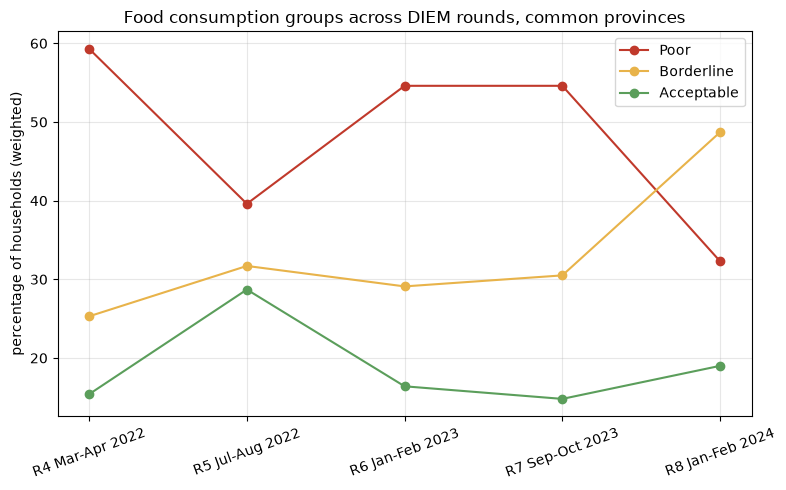

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
for c in CLASSES:
    ax.plot(trend.index, trend[c], marker='o', color=COLOURS[c], label=c)
ax.set_ylabel('percentage of households (weighted)')
ax.set_title('Food consumption groups across DIEM rounds, common provinces')
ax.legend(title='')
ax.grid(alpha=0.3)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('fig_fcg_by_round.png', dpi=200)
plt.show()

## 6. How did the shocks change?

The shock questions are coded identically in every round, so they are directly comparable.

In [7]:
shock_cols = sorted(set.intersection(*[{c for c in d.columns if c.startswith('shock_')}
                                       for d in rounds.values()]))

shock_trend = pd.DataFrame({
    ROUNDS[r]: d[d['adm1_name'].isin(common_all)][shock_cols].eq('Yes').mean() * 100
    for r, d in rounds.items()}).round(1)
shock_trend['change R4 to R8'] = (shock_trend[ROUNDS[8]] - shock_trend[ROUNDS[4]]).round(1)

print(shock_trend.sort_values(ROUNDS[8], ascending=False).head(12))
shock_trend.to_csv('results_shocks_by_round.csv')

                           R4 Mar-Apr 2022  R5 Jul-Aug 2022  R6 Jan-Feb 2023  R7 Sep-Oct 2023  R8 Jan-Feb 2024  change R4 to R8
shock_drought                         40.5             71.2             51.8             55.0             68.2             27.7
shock_higherfoodprices                77.6             88.1             76.4             52.0             63.7            -13.9
shock_plantdisease                    20.0             42.8             29.4             23.8             42.9             22.9
shock_sicknessordeathofhh             20.2             22.2             24.1             24.2             37.0             16.8
shock_othereconomicshock              10.8              4.8             11.3              8.7             23.5             12.7
shock_lostemplorwork                  18.9             18.2             19.4             14.7             22.4              3.5
shock_coldtemporhail                   7.2              2.9             40.9              7.4           

# PART B — Additional analysis: do the predictive relationships hold over time?

Limitation that applies to everything in this part: a difference between rounds may reflect genuine change over time, but also the harmonisation needed to make the rounds comparable. The two cannot be fully separated.

## 7. Is the geography of food insecurity stable?

Province was the strongest predictor in every model, so whether provinces keep their relative position matters for whether a model can travel across rounds.

In [8]:
def poor_share(d, provs):
    s = d[d['adm1_name'].isin(provs)]
    return s.groupby('adm1_name')['fcg'].apply(lambda x: (x == 'Poor').mean() * 100)

p6, p8 = poor_share(rounds[6], common_68), poor_share(rounds[8], common_68)

province_change = pd.DataFrame({'R6 Poor %': p6.round(1), 'R8 Poor %': p8.round(1)})
province_change['change'] = (province_change['R8 Poor %'] - province_change['R6 Poor %']).round(1)
print(province_change.sort_values('change').to_string())

print()
print('correlation between the two rounds')
print('  Pearson: ', round(p6.corr(p8), 3))
print('  Spearman:', round(p6.corr(p8, method='spearman'), 3))
province_change.to_csv('results_province_change.csv')

               R6 Poor %  R8 Poor %  change
adm1_name                                  
Hilmand             78.4       12.5   -65.9
Maidan Wardak       79.7       19.6   -60.1
Parwan              83.3       23.4   -59.9
Badakhshan          93.1       34.1   -59.0
Faryab              67.9       15.1   -52.8
Hirat               54.3       11.1   -43.2
Jawzjan             74.2       34.3   -39.9
Bamyan              97.2       67.5   -29.7
Nuristan            44.4       14.9   -29.5
Takhar              68.3       39.2   -29.1
Khost               88.6       61.1   -27.5
Nangarhar           72.2       46.2   -26.0
Kunar               38.1       12.6   -25.5
Samangan            72.2       48.6   -23.6
Daykundi            88.2       65.3   -22.9
Balkh               95.4       73.6   -21.8
Ghor                90.8       74.3   -16.5
Kandahar            25.1        9.0   -16.1
Kabul               37.3       25.1   -12.2
Nimroz              55.4       43.4   -12.0
Kunduz              42.7       5

## 8. Preparing Rounds 6 and 8 for the transfer test

Rounds 6 and 8 were both collected in January and February, one year apart, so the season is held constant. Categories that appear in only one of the two rounds are grouped as Other, so the two rounds describe the same things.

In [9]:
r6 = rounds[6][rounds[6]['adm1_name'].isin(common_68)].copy()
r8 = rounds[8][rounds[8]['adm1_name'].isin(common_68)].copy()

features = sorted(set(r6.columns) & set(r8.columns) - {'fcg', 'round', 'weight_final'})

for c in ['income_main', 'income_sec', 'ls_main', 'crp_main']:
    shared = set(r6[c]) & set(r8[c])
    r6[c] = r6[c].where(r6[c].isin(shared), 'Other')
    r8[c] = r8[c].where(r8[c].isin(shared), 'Other')

cat = [c for c in features if not pd.api.types.is_numeric_dtype(r8[c])]
num = [c for c in features if c not in cat]

print('Round 6:', len(r6), 'households | Round 8:', len(r8), 'households')
print('harmonised predictors:', len(features))

Round 6: 6070 households | Round 8: 7313 households
harmonised predictors: 44


## 9. Multicollinearity among the harmonised predictors

Checked before any importance is interpreted, as in notebook 02. The three redundant variables removed in notebook 02 do not exist in Round 6, so they are absent from this set, and this cell confirms that no other pair is close to redundant.

In [10]:
def cramers_v(a, b):
    table = pd.crosstab(a, b)
    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan
    chi2 = chi2_contingency(table)[0]
    n = table.values.sum()
    r, k = table.shape
    phi2c = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2c / max(1e-12, min(kc - 1, rc - 1)))

for name, d in [('Round 6', r6), ('Round 8', r8)]:
    values = [cramers_v(d[a], d[b]) for a, b in combinations(cat, 2)]
    values = [v for v in values if v == v]
    print(name, '| highest Cramer\'s V between harmonised predictors:', round(max(values), 3),
          '| pairs above 0.9:', sum(v > 0.9 for v in values))

Round 6 | highest Cramer's V between harmonised predictors: 0.631 | pairs above 0.9: 0
Round 8 | highest Cramer's V between harmonised predictors: 0.638 | pairs above 0.9: 0


## 10. Does a model trained on Round 6 still work on Round 8?

Three models are compared on exactly the same variables and provinces. The transfer model is trained on Round 6 and tested on Round 8. The other two are trained and tested within a single round, so any gap reflects the difference between the rounds rather than a difference in the data available.

In [11]:
def make_model():
    return Pipeline([
        ('prep', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat),
                                    ('num', StandardScaler(), num)])),
        ('model', XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.08,
                                subsample=0.9, colsample_bytree=0.8,
                                random_state=RANDOM_STATE, eval_metric='mlogloss'))])

transfer = make_model()
transfer.fit(r6[features], r6['fcg'].map(YMAP))
pred_transfer = pd.Series(transfer.predict(r8[features])).map(INV).values

X8tr, X8te, y8tr, y8te = train_test_split(r8[features], r8['fcg'], test_size=0.25,
                                          random_state=RANDOM_STATE, stratify=r8['fcg'])
within8 = make_model()
within8.fit(X8tr, y8tr.map(YMAP))
pred8 = pd.Series(within8.predict(X8te)).map(INV).values

X6tr, X6te, y6tr, y6te = train_test_split(r6[features], r6['fcg'], test_size=0.25,
                                          random_state=RANDOM_STATE, stratify=r6['fcg'])
within6 = make_model()
within6.fit(X6tr, y6tr.map(YMAP))
pred6 = pd.Series(within6.predict(X6te)).map(INV).values

comparison = pd.DataFrame({
    'accuracy': [accuracy_score(r8['fcg'], pred_transfer),
                 accuracy_score(y8te, pred8),
                 accuracy_score(y6te, pred6)],
    'macro F1': [f1_score(r8['fcg'], pred_transfer, average='macro'),
                 f1_score(y8te, pred8, average='macro'),
                 f1_score(y6te, pred6, average='macro')],
}, index=['trained R6, tested R8', 'trained R8, tested R8', 'trained R6, tested R6'])
comparison.loc['majority class in R8'] = [r8['fcg'].value_counts(normalize=True).max(), np.nan]
print(comparison.round(3))
comparison.round(3).to_csv('results_transfer.csv')

                       accuracy  macro F1
trained R6, tested R8     0.444     0.395
trained R8, tested R8     0.735     0.730
trained R6, tested R6     0.764     0.690
majority class in R8      0.433       NaN


## 11. Why does the transfer fail?

If only the proportions of the three categories changed between rounds, the model would still rank households correctly and simply misplace the cut offs. If the relationships themselves changed, the ranking would also degrade. The area under the curve separates the two, because it does not depend on the proportions.

In [12]:
print('actual distribution in Round 8:')
print((r8['fcg'].value_counts(normalize=True) * 100).round(1).to_dict())
print('what the Round 6 model predicted for Round 8:')
print((pd.Series(pred_transfer).value_counts(normalize=True) * 100).round(1).to_dict())
print('distribution the model learned from Round 6:')
print((r6['fcg'].value_counts(normalize=True) * 100).round(1).to_dict())
print()
print(classification_report(r8['fcg'], pred_transfer, zero_division=0))

auc_transfer = roc_auc_score(r8['fcg'].map(YMAP), transfer.predict_proba(r8[features]),
                             multi_class='ovr', average='macro')
auc_within = roc_auc_score(y8te.map(YMAP), within8.predict_proba(X8te),
                           multi_class='ovr', average='macro')
print('macro one versus rest area under the curve')
print('  trained R6, tested R8:', round(auc_transfer, 3))
print('  trained R8, tested R8:', round(auc_within, 3))

actual distribution in Round 8:
{'Borderline': 43.3, 'Poor': 36.9, 'Acceptable': 19.8}
what the Round 6 model predicted for Round 8:
{'Poor': 61.9, 'Borderline': 20.3, 'Acceptable': 17.8}
distribution the model learned from Round 6:
{'Poor': 56.7, 'Borderline': 25.2, 'Acceptable': 18.1}

              precision    recall  f1-score   support

  Acceptable       0.28      0.25      0.26      1448
  Borderline       0.55      0.26      0.35      3168
        Poor       0.46      0.77      0.57      2697

    accuracy                           0.44      7313
   macro avg       0.43      0.42      0.40      7313
weighted avg       0.46      0.44      0.42      7313

macro one versus rest area under the curve
  trained R6, tested R8: 0.633
  trained R8, tested R8: 0.881


## 12. Are the same variables important in each round?

The same model is fitted separately in each round, on the common provinces, and the variables are ranked by permutation importance. Only the top of the ranking should be interpreted, since the ranks lower down move considerably between rounds. This cell takes several minutes.

In [13]:
importance_by_round = {}

for r in [4, 5, 6, 7, 8]:
    d = rounds[r][rounds[r]['adm1_name'].isin(common_all)].copy()
    feats = [c for c in features if c in d.columns]
    for c in ['income_main', 'income_sec', 'ls_main', 'crp_main']:
        if c in feats:
            d[c] = d[c].where(d[c].isin(set(r8[c])), 'Other')
    cats = [c for c in feats if not pd.api.types.is_numeric_dtype(d[c])]
    nums = [c for c in feats if c not in cats]
    Xtr, Xte, ytr, yte = train_test_split(d[feats], d['fcg'], test_size=0.25,
                                          random_state=RANDOM_STATE, stratify=d['fcg'])
    p = Pipeline([('prep', ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cats),
                                              ('num', StandardScaler(), nums)])),
                  ('model', XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                                          subsample=0.9, colsample_bytree=0.8,
                                          random_state=RANDOM_STATE, eval_metric='mlogloss'))])
    p.fit(Xtr, ytr.map(YMAP))
    perm = permutation_importance(p, Xte, yte.map(YMAP), n_repeats=3,
                                  random_state=RANDOM_STATE, n_jobs=-1, scoring='accuracy')
    importance_by_round[ROUNDS[r]] = pd.Series(perm.importances_mean, index=feats)
    print('done', ROUNDS[r])

imp = pd.DataFrame(importance_by_round)
top = imp.loc[imp.mean(axis=1).sort_values(ascending=False).head(12).index]
print()
print((top * 100).round(2))
imp.to_csv('results_importance_by_round.csv')

done R4 Mar-Apr 2022
done R5 Jul-Aug 2022
done R6 Jan-Feb 2023
done R7 Sep-Oct 2023
done R8 Jan-Feb 2024

                           R4 Mar-Apr 2022  R5 Jul-Aug 2022  R6 Jan-Feb 2023  R7 Sep-Oct 2023  R8 Jan-Feb 2024
adm1_name                             8.66            24.95            19.10            16.69            22.18
tot_income                            0.15             2.06             4.29             1.94             2.93
ls_main                               1.12             0.90             1.09             0.54             1.25
n_shocks                              0.98             0.53             0.62             0.30             2.08
hh_wealth_light                        NaN             0.51             0.36             1.94             0.22
income_main_comp                     -0.17             0.88             0.43             0.63             1.54
income_sec                            0.59             0.42             0.28             0.42             1.13
crp_ar

In [14]:
ranks = imp.rank(ascending=False).loc[top.index].round(0).astype('Int64')
print('RANK OF EACH VARIABLE IN EACH ROUND (1 = most important)')
print('a blank means the variable was not collected in that round')
print(ranks)

RANK OF EACH VARIABLE IN EACH ROUND (1 = most important)
a blank means the variable was not collected in that round
                           R4 Mar-Apr 2022  R5 Jul-Aug 2022  R6 Jan-Feb 2023  R7 Sep-Oct 2023  R8 Jan-Feb 2024
adm1_name                                1                1                1                1                1
tot_income                              11                2                2                2                2
ls_main                                  2                4                3                9                5
n_shocks                                 3                8                6               17                3
hh_wealth_light                       <NA>               10               14                2               26
income_main_comp                        39                5               12                6                4
income_sec                               5               12               18               12              

## 13. Summary for the writing

In [15]:
print('PART A')
print('Poor share across rounds, common provinces, weighted:')
print(trend[['Poor']].T.to_string())
print()
print('PART B')
print('Province correlation between Round 6 and Round 8 (Spearman):', round(p6.corr(p8, method='spearman'), 3))
print()
print(comparison.round(3).to_string())
print()
print('area under the curve, transfer versus within round:', round(auc_transfer, 3), 'versus', round(auc_within, 3))

PART A
Poor share across rounds, common provinces, weighted:
      R4 Mar-Apr 2022  R5 Jul-Aug 2022  R6 Jan-Feb 2023  R7 Sep-Oct 2023  R8 Jan-Feb 2024
fcg                                                                                      
Poor             59.3             39.6             54.6             54.6             32.3

PART B
Province correlation between Round 6 and Round 8 (Spearman): 0.487

                       accuracy  macro F1
trained R6, tested R8     0.444     0.395
trained R8, tested R8     0.735     0.730
trained R6, tested R6     0.764     0.690
majority class in R8      0.433       NaN

area under the curve, transfer versus within round: 0.633 versus 0.881


## 14. Are the same FCG thresholds used in every round?

Between Rounds 6 and 8 the fall in the Poor share went mostly into Borderline. A change in the threshold between Poor and Borderline could produce the same pattern, so the thresholds are checked directly in the original files, using the score and the group recorded for each household.

In [16]:
RAW = {4: 'data_anon.xlsx', 5: 'anon_dfAFG_R5.xlsx', 6: 'data_anon_AFG_R6.csv',
       7: 'anon_df_AFG_R7.csv', 8: 'anon_dfAFG_R8.xlsx'}
RAW_FCG = {1: 'Poor', 2: 'Borderline', 3: 'Acceptable',
           'Poor': 'Poor', 'Moderate': 'Borderline', 'Acceptable': 'Acceptable'}

rows = []
for r, f in RAW.items():
    raw = pd.read_excel(f) if f.endswith('.xlsx') else pd.read_csv(f, low_memory=False)
    t = pd.DataFrame({'fcs': pd.to_numeric(raw['fcs'], errors='coerce'),
                      'fcg': raw['fcg'].map(RAW_FCG),
                      'w': raw['weight_final']}).dropna(subset=['fcs', 'fcg'])
    away = t[(t['fcs'] != 28) & (t['fcs'] != 42)]
    rule = np.where(away['fcs'] < 28, 'Poor', np.where(away['fcs'] < 42, 'Borderline', 'Acceptable'))
    at28 = t[t['fcs'] == 28]
    rows.append({'round': ROUNDS[r],
                 'Poor scores': f"{t.loc[t['fcg'] == 'Poor', 'fcs'].min():g} to {t.loc[t['fcg'] == 'Poor', 'fcs'].max():g}",
                 'Borderline scores': f"{t.loc[t['fcg'] == 'Borderline', 'fcs'].min():g} to {t.loc[t['fcg'] == 'Borderline', 'fcs'].max():g}",
                 'Acceptable scores': f"{t.loc[t['fcg'] == 'Acceptable', 'fcs'].min():g} to {t.loc[t['fcg'] == 'Acceptable', 'fcs'].max():g}",
                 'against the 28/42 rule': int((rule != away['fcg']).sum()),
                 'score 28, % Poor': round((at28['fcg'] == 'Poor').mean() * 100, 1),
                 'score 28, weighted % of all': round(at28['w'].sum() / t['w'].sum() * 100, 1)})
print(pd.DataFrame(rows).set_index('round').to_string())

                Poor scores Borderline scores Acceptable scores  against the 28/42 rule  score 28, % Poor  score 28, weighted % of all
round                                                                                                                                 
R4 Mar-Apr 2022     0 to 28          28 to 42         42 to 108                       0              73.4                          4.1
R5 Jul-Aug 2022     0 to 28          28 to 42          42 to 92                       0              71.7                          3.3
R6 Jan-Feb 2023     0 to 28          28 to 42         42 to 112                       0              68.8                          5.0
R7 Sep-Oct 2023     0 to 28          28 to 42          42 to 87                       0              69.9                          4.2
R8 Jan-Feb 2024     0 to 28          28 to 42          42 to 93                       0              70.1                          5.4


**What the result shows.** In every round, households scoring below 28 are always Poor, households scoring above 42 are always Acceptable, and no household is classified against the 28 and 42 rule. Only households with a score of exactly 28 are split between Poor and Borderline, and they are split in the same way in every round, about 70 percent Poor in both Round 6 and Round 8. They are also only about 5 percent of the weighted population in each round, far too few to explain a fall of 22 points in the Poor share. The thresholds are the same in all rounds, so the shift from Poor to Borderline between Rounds 6 and 8 is not caused by a change in the thresholds.

## 15. Weighted shocks and weighted provincial shares

The shares of shocks in section 6 and the provincial Poor shares in section 7 describe the households interviewed. This section repeats both with the survey weights, on the same provinces.

In [17]:
def weighted_yes(d, cols):
    w = d['weight_final']
    return d[cols].eq('Yes').mul(w, axis=0).sum() / w.sum() * 100

weighted_shocks = pd.DataFrame({ROUNDS[r]: weighted_yes(d[d['adm1_name'].isin(common_all)], shock_cols)
                                for r, d in rounds.items()}).round(1)
weighted_shocks['change R4 to R8'] = (weighted_shocks[ROUNDS[8]] - weighted_shocks[ROUNDS[4]]).round(1)
print(weighted_shocks.sort_values(ROUNDS[8], ascending=False).head(12).to_string())
weighted_shocks.to_csv('results_shocks_by_round_weighted.csv')

                           R4 Mar-Apr 2022  R5 Jul-Aug 2022  R6 Jan-Feb 2023  R7 Sep-Oct 2023  R8 Jan-Feb 2024  change R4 to R8
shock_higherfoodprices                78.2             89.0             77.0             52.5             63.7            -14.5
shock_drought                         46.9             72.8             50.0             55.3             59.9             13.0
shock_sicknessordeathofhh             23.8             27.0             26.8             19.6             40.2             16.4
shock_plantdisease                    22.2             49.2             32.3             31.7             34.8             12.6
shock_lostemplorwork                  26.2             28.0             29.5             17.5             25.2             -1.0
shock_othereconomicshock              12.9              5.0             14.5             12.2             23.7             10.8
shock_higherfuelprices                42.8             74.6             56.7             21.4           

In [18]:
def weighted_poor_share(d, provs):
    s = d[d['adm1_name'].isin(provs)]
    return s.groupby('adm1_name').apply(
        lambda g: g.loc[g['fcg'] == 'Poor', 'weight_final'].sum() / g['weight_final'].sum() * 100)

wp6, wp8 = weighted_poor_share(rounds[6], common_68), weighted_poor_share(rounds[8], common_68)
print('correlation of the weighted provincial Poor shares, Round 6 and Round 8')
print('  Pearson: ', round(wp6.corr(wp8), 3))
print('  Spearman:', round(wp6.corr(wp8, method='spearman'), 3))

correlation of the weighted provincial Poor shares, Round 6 and Round 8
  Pearson:  0.37
  Spearman: 0.429


**What the result shows.** With the survey weights, drought and sickness or death of a household member still become clearly more common between Round 6 and Round 8, from 50.0 to 59.9 percent and from 26.8 to 40.2 percent, while higher food and fuel prices become less common. The rise in plant disease is much smaller than without weights, from 32.3 to 34.8 percent. The weighted provincial Poor shares of the two rounds have a rank correlation of 0.43, against 0.49 without weights, so with or without weights many provinces change position between the two years.

## 16. Categories not seen during training

A model can only use the categories it saw during training. The transfer test handles this in two ways. In section 8, categories of main income, second income, main livestock and main crop that appear in only one of the two rounds are grouped as Other. Any category that the Round 6 model still never saw is encoded as zero in every dummy column, because the encoder is set to ignore unknown categories. The first cell counts how many Round 8 households are affected.

In [19]:
unseen = pd.Series(False, index=r8.index)
for c in cat:
    unseen |= ~r8[c].astype(str).isin(set(r6[c].astype(str)))
print('Round 8 households with a category never seen in Round 6:', int(unseen.sum()), 'of', len(r8))
print('households grouped as Other for main income source: Round 6',
      int((r6['income_main'] == 'Other').sum()), 'of', len(r6), '| Round 8',
      int((r8['income_main'] == 'Other').sum()), 'of', len(r8))

Round 8 households with a category never seen in Round 6: 0 of 7313
households grouped as Other for main income source: Round 6 3994 of 6070 | Round 8 5309 of 7313


Several income categories are worded differently in the two rounds, for example "Production and sales of staple crops" in Round 6 and "Production and sale of staple crops" in Round 8. Section 8 therefore treats them as different categories and groups them as Other. The next cell matches the wording and repeats the transfer test, to check whether this affects the result.

In [20]:
SAME_INCOME = {
    'Production and sales of staple crops': 'Production and sale of staple crops',
    'Production and sale of vegetable or fruit': 'Production and sale of vegetables or fruit',
    'Informal agricultural trade excluding producers': 'Agricultural trade excluding producers (formal or informal)',
    'Formal agricultural trade excluding producers': 'Agricultural trade excluding producers (formal or informal)',
    'No income source in the last 3 months and used exclusively debt':
        'No income source in the last 3 months and used exclusively savings, debt',
    'No income source in the last 3 months and used exclusively savings':
        'No income source in the last 3 months and used exclusively savings, debt',
}
r6m = rounds[6][rounds[6]['adm1_name'].isin(common_68)].copy()
r8m = rounds[8][rounds[8]['adm1_name'].isin(common_68)].copy()
for c in ['income_main', 'income_sec']:
    r6m[c] = r6m[c].replace(SAME_INCOME)
    r8m[c] = r8m[c].replace(SAME_INCOME)
for c in ['income_main', 'income_sec', 'ls_main', 'crp_main']:
    shared = set(r6m[c]) & set(r8m[c])
    r6m[c] = r6m[c].where(r6m[c].isin(shared), 'Other')
    r8m[c] = r8m[c].where(r8m[c].isin(shared), 'Other')
print('households grouped as Other for main income source after matching: Round 6',
      int((r6m['income_main'] == 'Other').sum()), '| Round 8', int((r8m['income_main'] == 'Other').sum()))

transfer_m = make_model()
transfer_m.fit(r6m[features], r6m['fcg'].map(YMAP))
pred_m = pd.Series(transfer_m.predict(r8m[features])).map(INV).values

X8tr_m, X8te_m, y8tr_m, y8te_m = train_test_split(r8m[features], r8m['fcg'], test_size=0.25,
                                                  random_state=RANDOM_STATE, stratify=r8m['fcg'])
within8_m = make_model()
within8_m.fit(X8tr_m, y8tr_m.map(YMAP))
pred8_m = pd.Series(within8_m.predict(X8te_m)).map(INV).values

matched = pd.DataFrame({
    'accuracy': [accuracy_score(r8m['fcg'], pred_m), accuracy_score(y8te_m, pred8_m)],
    'macro F1': [f1_score(r8m['fcg'], pred_m, average='macro'), f1_score(y8te_m, pred8_m, average='macro')],
    'area under the curve': [
        roc_auc_score(r8m['fcg'].map(YMAP), transfer_m.predict_proba(r8m[features]), multi_class='ovr', average='macro'),
        roc_auc_score(y8te_m.map(YMAP), within8_m.predict_proba(X8te_m), multi_class='ovr', average='macro')],
}, index=['trained R6, tested R8', 'trained R8, tested R8']).round(3)
print()
print(matched)
matched.to_csv('results_transfer_matched_labels.csv')

households grouped as Other for main income source after matching: Round 6 0 | Round 8 1

                       accuracy  macro F1  area under the curve
trained R6, tested R8     0.448     0.404                 0.640
trained R8, tested R8     0.732     0.729                 0.882


**What the result shows.** No household in Round 8 has a category that the Round 6 model never saw, so the setting of the encoder does not affect the result. The different wording, however, placed most households in Other for main income source, 3,994 of 6,070 in Round 6 and 5,309 of 7,313 in Round 8. After matching the wording almost none are left in Other, but the transfer result hardly changes: the model trained on Round 6 still performs far worse on Round 8 than the model trained within Round 8. The failure of the transfer is therefore not caused by the wording of the income categories.